## baseline + LSTM

In [1]:
import shap
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df_match = pd.read_parquet('df_match.parquet')

## 根据选手的历史特征，去预测新的比赛结果

In [2]:
df_match.head()

,uid,Player,ELO,Target,Date,Δi_Hist,D_Hist,Is_Optimal_Hist,Is_Error_Hist,Is_Blunder_Hist,...,D_Hist_Diff,Is_Optimal_Hist_Diff,Is_Error_Hist_Diff,Is_Blunder_Hist_Diff,Cog_Speed_S1_Hist_Diff,Cog_Speed_S2_Hist_Diff,Cog_Speed_S3_Hist_Diff,TM_S1_Hist_Diff,TM_S2_Hist_Diff,TM_S3_Hist_Diff
0,906130,Alberto Barp,2590.0,-1.0,2020-03-04,0.515489,0.452265,0.596109,0.042447,0.025628,...,-0.047227,0.048248,-0.006961,0.008536,0.210064,-0.139083,-0.060317,0.009,0.098,0.237
1,906130,Krikor Sevag Mekhitarian,2826.0,1.0,2020-03-04,21.448369,0.499492,0.547861,0.049408,0.017091,...,0.047227,-0.048248,0.006961,-0.008536,-0.210064,0.139083,0.060317,-0.009,-0.098,-0.237
2,906151,Maksim Chigaev,2901.0,1.0,2020-03-04,43.069367,0.463297,0.625794,0.039385,0.016282,...,-0.039368,0.047202,-0.013699,-0.006000,-0.643110,-0.231066,-0.764103,0.014,0.001,-0.258
3,906151,Ronald Brizuela,2624.0,-1.0,2020-03-04,93.113105,0.502665,0.578591,0.053084,0.022282,...,0.039368,-0.047202,0.013699,0.006000,0.643110,0.231066,0.764103,-0.014,-0.001,0.258
4,906176,Chelsie Monica Ignesias Sihite,2160.0,1.0,2020-03-04,125.572323,0.493892,0.416379,0.094040,0.057624,...,-0.041179,-0.182185,0.024030,0.017090,0.440413,-0.241951,-0.316492,-0.015,-0.201,-0.290


In [3]:
df_match.columns

Index(['uid', 'Player', 'ELO', 'Target', 'Date', 'Δi_Hist', 'D_Hist',
       'Is_Optimal_Hist', 'Is_Error_Hist', 'Is_Blunder_Hist',
       'Cog_Speed_S1_Hist', 'Cog_Speed_S2_Hist', 'Cog_Speed_S3_Hist',
       'TM_S1_Hist', 'TM_S2_Hist', 'TM_S3_Hist', 'Player_Opp', 'ELO_Opp',
       'Target_Opp', 'Δi_Hist_Opp', 'D_Hist_Opp', 'Is_Optimal_Hist_Opp',
       'Is_Error_Hist_Opp', 'Is_Blunder_Hist_Opp', 'Cog_Speed_S1_Hist_Opp',
       'Cog_Speed_S2_Hist_Opp', 'Cog_Speed_S3_Hist_Opp', 'TM_S1_Hist_Opp',
       'TM_S2_Hist_Opp', 'TM_S3_Hist_Opp', 'ELO_Diff', 'Δi_Hist_Diff',
       'D_Hist_Diff', 'Is_Optimal_Hist_Diff', 'Is_Error_Hist_Diff',
       'Is_Blunder_Hist_Diff', 'Cog_Speed_S1_Hist_Diff',
       'Cog_Speed_S2_Hist_Diff', 'Cog_Speed_S3_Hist_Diff', 'TM_S1_Hist_Diff',
       'TM_S2_Hist_Diff', 'TM_S3_Hist_Diff'],
      dtype='object')

In [10]:
df_match = df_match.copy()
df_match = df_match[df_match['Target'] != 0.0].reset_index(drop=True)
df_match = df_match.sort_values('Date')
df_match = df_match.groupby('uid').first().reset_index()

drop_cols = ['uid', 'Player', 'Player_Opp', 'Date', 'Target', 'Target_Opp',
             'ELO', 'ELO_Diff', 'ELO_Opp',
             'Δi_Hist','D_Hist','Is_Optimal_Hist','Is_Error_Hist','Is_Blunder_Hist',
             'Cog_Speed_S1_Hist','Cog_Speed_S2_Hist','Cog_Speed_S3_Hist',
             'TM_S1_Hist','TM_S2_Hist','TM_S3_Hist',
             'Δi_Hist_Opp','D_Hist_Opp','Is_Optimal_Hist_Opp','Is_Error_Hist_Opp','Is_Blunder_Hist_Opp',
             'Cog_Speed_S1_Hist_Opp','Cog_Speed_S2_Hist_Opp','Cog_Speed_S3_Hist_Opp',
             'TM_S1_Hist_Opp','TM_S2_Hist_Opp','TM_S3_Hist_Opp'
             ]
features = [col for col in df_match.columns if col not in drop_cols]

X = df_match[features]
y = df_match['Target'] 
label_mapping = {-1.0: 0, 1.0: 1}
y_mapped = y.map(label_mapping)

# 时序划分
# 找到 80% 时间点对应的日期
split_date = df_match['Date'].sort_values().iloc[int(len(df_match) * 0.8)]
# 基于时间切分，防止时序泄露
train_df = df_match[df_match['Date'] < split_date]
test_df = df_match[df_match['Date'] >= split_date]

X_train = train_df[features]
y_train = train_df['Target'].map({-1.0: 0, 1.0: 1})
X_test = test_df[features]
y_test = test_df['Target'].map({-1.0: 0, 1.0: 1})

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"训练集标签分布:\n{y_train.value_counts()}")

# 二分类 LightGBM 
clf = lgb.LGBMClassifier(
    n_estimators=200,      
    learning_rate=0.05,    
    max_depth=5,           
    objective='binary',  # 改为二分类
    random_state=42,
    n_jobs=-1              
)
clf.fit(X_train, y_train)

# 二分类预测与评估
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # 预测为赢的概率

print("\n=== 模型评估报告（二分类：只看胜负）===")
target_names = ['Loss (-1.0)', 'Win (1.0)']
print(classification_report(y_test, y_pred, target_names=target_names))

# 二分类核心指标
print(f"\n准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC (ROC): {roc_auc_score(y_test, y_prob):.4f}")

训练集大小: (475125, 11), 测试集大小: (121071, 11)
训练集标签分布:
Target
1    241596
0    233529
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 241596, number of negative: 233529
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004998 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 475125, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508489 -> initscore=0.033961
[LightGBM] [Info] Start training from score 0.033961
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

In [11]:
X_train.columns.tolist()

['Δi_Hist_Diff',
 'D_Hist_Diff',
 'Is_Optimal_Hist_Diff',
 'Is_Error_Hist_Diff',
 'Is_Blunder_Hist_Diff',
 'Cog_Speed_S1_Hist_Diff',
 'Cog_Speed_S2_Hist_Diff',
 'Cog_Speed_S3_Hist_Diff',
 'TM_S1_Hist_Diff',
 'TM_S2_Hist_Diff',
 'TM_S3_Hist_Diff']

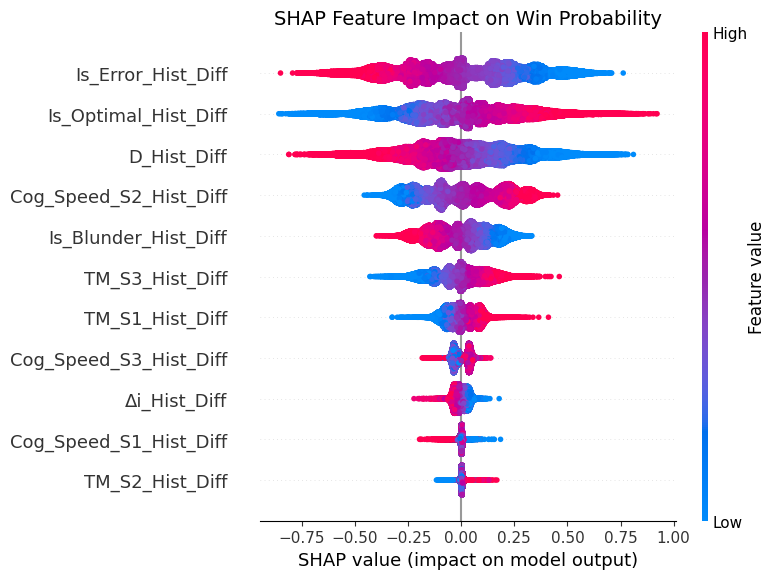

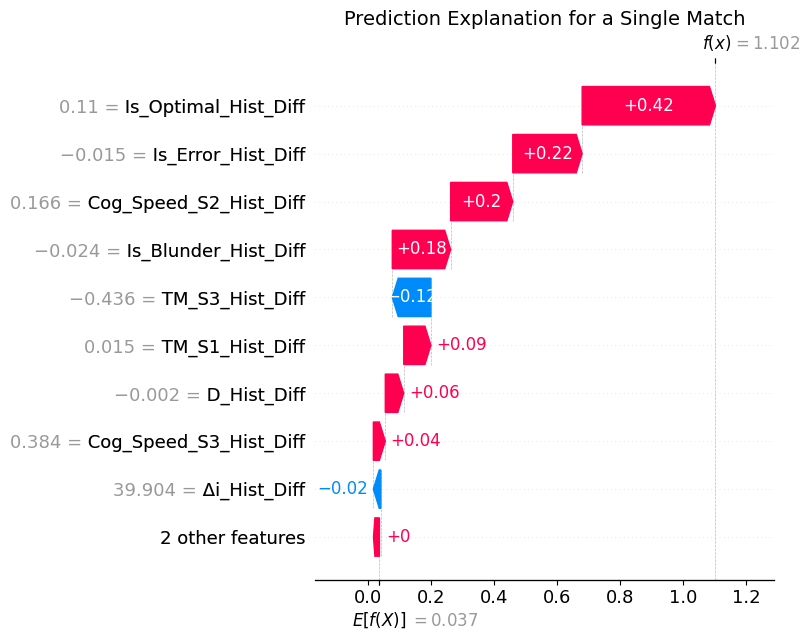

警告：特征库中没找到 Time_Management_Score_Hist


In [12]:
plt.style.use('default') 

# SHAP Explainer
explainer = shap.Explainer(clf)
shap_values_obj = explainer(X_test)

# 如果你的 lightGBM 版本导致 SHAP 输出具有第三个维度(二分类的两个类)，提取正类(Index 1)
if len(shap_values_obj.shape) == 3:
    shap_values_obj = shap_values_obj[:, :, 1]

# Figure 1: 蜂群图
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_obj, max_display=15, show=False)
plt.title("SHAP Feature Impact on Win Probability", fontsize=14)
plt.tight_layout()
plt.show()

# Figure 2: 单独一局游戏样本
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_obj[0], max_display=10, show=False)
plt.title("Prediction Explanation for a Single Match", fontsize=14)
plt.tight_layout()
plt.show()

# Figure 3: 某个特征的趋势图
try:
    # 定义想查看的特征名称
    target_feature = "Time_Management_Score_Hist"
    color_feature = "ELO"
    
    # 手动通过列名查找对应的数字索引
    feature_names_list = list(X_test.columns)
    if target_feature in feature_names_list:
        idx_target = feature_names_list.index(target_feature)
        
        idx_color = None
        if color_feature in feature_names_list:
            idx_color = feature_names_list.index(color_feature)
            color_setting = shap_values_obj[:, idx_color]
        else:
            color_setting = shap_values_obj # SHAP 自动选择最相关的特征

        plt.figure(figsize=(8, 5))
        shap.plots.scatter(
            shap_values_obj[:, idx_target], 
            color=color_setting, 
            show=False
        )
        plt.title(f"Dependence Plot: {target_feature}", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"警告：特征库中没找到 {target_feature}")

except Exception as e:
    print(f"图 3 绘制失败，错误原因: {e}")